# 03 — Price Elasticity Modelling

## Retail Pricing and Promotion Optimization

This notebook estimates product-level price elasticity using the synthetic retail dataset.

### Objectives

- Prepare a suitable dataset for elasticity estimation
- Examine within-product price variation
- Estimate a simple log-log demand model
- Estimate an adjusted model with business controls
- Calculate product-level elasticities
- Compare estimated elasticities with known synthetic values
- Simulate price, demand, and revenue scenarios

> The estimates in this notebook are associational. Price may be influenced by expected demand, promotions, seasonality, and other business decisions. A causal IV/2SLS model will be developed in the next notebook.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf


PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.4f}".format)

print(f"Project root: {PROJECT_ROOT}")

Project root: c:\Users\marja\OneDrive\Desktop\GitHub\retail-pricing-promotion-optimization


In [2]:
from src.data.io import load_synthetic_retail_data


retail = load_synthetic_retail_data()
retail["date"] = pd.to_datetime(retail["date"])

print(f"Dataset shape: {retail.shape}")
print(
    f"Date range: {retail['date'].min().date()} "
    f"to {retail['date'].max().date()}"
)

retail.head()

Dataset shape: (18300, 29)
Date range: 2024-01-01 to 2024-12-31


,date,store_id,region,product_id,category,year,month,day_of_week,weekend_flag,holiday_flag,regular_price,selling_price,competitor_price,unit_cost,discount_pct,promotion_flag,promotion_type,promotion_propensity,advertising_spend,supplier_cost_index,shipping_cost_index,weather_index,customer_traffic,inventory_level,stockout_flag,units_sold,revenue,gross_profit,true_price_elasticity
0,2024-01-01,S001,West,P001,Beverages,2024,1,Monday,0,1,4.2900,4.2900,4.2800,2.1200,0.0000,0,none,0.2300,17.8700,1.0024,1.0188,0.5661,1206,71,0,47,201.8300,102.4100,-1.8000
1,2024-01-01,S001,West,P002,Beverages,2024,1,Monday,0,1,7.1600,7.1600,6.9300,3.2200,0.0000,0,none,0.2300,20.9500,1.0024,1.0188,0.5661,1206,52,0,50,357.9900,196.8100,-2.1000
2,2024-01-01,S001,West,P003,Beverages,2024,1,Monday,0,1,9.8400,9.8400,9.7900,4.6300,0.0000,0,none,0.2300,22.2600,1.0024,1.0188,0.5661,1206,55,0,26,255.7300,135.2600,-2.4000
3,2024-01-01,S001,West,P004,Grocery,2024,1,Monday,0,1,4.2000,4.2000,4.0800,1.7600,0.0000,0,none,0.2000,22.9300,1.0024,1.0188,0.5661,1206,120,0,91,382.6200,222.2000,-1.4000
4,2024-01-01,S001,West,P005,Grocery,2024,1,Monday,0,1,5.4900,5.4900,5.7400,2.5700,0.0000,0,none,0.2000,12.6800,1.0024,1.0188,0.5661,1206,54,1,54,296.5400,157.8300,-1.7000


In [3]:
elasticity_data = retail.loc[
    (retail["units_sold"] > 0)
    & (retail["selling_price"] > 0)
    & (retail["competitor_price"] > 0)
    & (retail["stockout_flag"] == 0)
].copy()

elasticity_data["log_units_sold"] = np.log(
    elasticity_data["units_sold"]
)

elasticity_data["log_selling_price"] = np.log(
    elasticity_data["selling_price"]
)

elasticity_data["log_competitor_price"] = np.log(
    elasticity_data["competitor_price"]
)

elasticity_data["log_customer_traffic"] = np.log(
    elasticity_data["customer_traffic"]
)

elasticity_data["log_advertising_spend"] = np.log1p(
    elasticity_data["advertising_spend"]
)

sample_summary = pd.Series(
    {
        "Original observations": len(retail),
        "Elasticity observations": len(elasticity_data),
        "Excluded observations": (
            len(retail) - len(elasticity_data)
        ),
        "Products": elasticity_data["product_id"].nunique(),
        "Stores": elasticity_data["store_id"].nunique(),
        "Minimum selling price": (
            elasticity_data["selling_price"].min()
        ),
        "Maximum selling price": (
            elasticity_data["selling_price"].max()
        ),
    },
    name="Value",
)

sample_summary.to_frame()

,Value
Original observations,"18,300.0000"
Elasticity observations,"14,272.0000"
Excluded observations,"4,028.0000"
Products,10.0000
Stores,5.0000
Minimum selling price,2.8500
Maximum selling price,14.0400


In [4]:
price_variation = (
    elasticity_data.groupby(
        ["product_id", "category"],
        as_index=False,
    )
    .agg(
        observations=("units_sold", "size"),
        minimum_price=("selling_price", "min"),
        average_price=("selling_price", "mean"),
        maximum_price=("selling_price", "max"),
        price_standard_deviation=(
            "selling_price",
            "std",
        ),
        average_units_sold=("units_sold", "mean"),
        true_elasticity=(
            "true_price_elasticity",
            "first",
        ),
    )
)

price_variation["price_range_pct"] = (
    (
        price_variation["maximum_price"]
        - price_variation["minimum_price"]
    )
    / price_variation["average_price"]
    * 100
)

price_variation

,product_id,category,observations,minimum_price,average_price,maximum_price,price_standard_deviation,average_units_sold,true_elasticity,price_range_pct
0,P001,Beverages,1420,3.1300,4.3805,4.9500,0.2986,50.0444,-1.8000,41.5479
1,P002,Beverages,1426,4.7300,6.8268,7.7400,0.4665,39.1466,-2.1000,44.0912
2,P003,Beverages,1416,6.6400,9.2783,10.5200,0.6357,29.3573,-2.4000,41.8181
3,P004,Grocery,1476,2.8500,3.9130,4.3500,0.2449,57.2846,-1.4000,38.3340
4,P005,Grocery,1433,3.8000,5.3809,6.0300,0.3661,46.5422,-1.7000,41.4430
5,P006,Grocery,1431,6.3100,8.7856,9.8300,0.6035,32.3969,-2.0000,40.0654
6,P007,Household,1413,5.2400,7.3116,8.2900,0.5311,24.6108,-1.2000,41.7148
7,P008,Household,1419,8.9000,12.7066,14.0400,0.8455,18.4545,-1.5000,40.4513
8,P009,Personal Care,1424,4.4900,6.3530,7.1600,0.4334,30.0253,-1.3000,42.0272
9,P010,Personal Care,1414,7.6500,10.7602,12.1100,0.7015,21.1697,-1.6000,41.4492


In [5]:
simple_model = smf.ols(
    formula=(
        "log_units_sold ~ log_selling_price"
    ),
    data=elasticity_data,
).fit(cov_type="HC3")

simple_elasticity = simple_model.params[
    "log_selling_price"
]

simple_ci = simple_model.conf_int().loc[
    "log_selling_price"
]

simple_result = pd.Series(
    {
        "Estimated elasticity": simple_elasticity,
        "Robust standard error": simple_model.bse[
            "log_selling_price"
        ],
        "Lower 95% confidence limit": simple_ci.iloc[0],
        "Upper 95% confidence limit": simple_ci.iloc[1],
        "P-value": simple_model.pvalues[
            "log_selling_price"
        ],
        "R-squared": simple_model.rsquared,
        "Observations": int(simple_model.nobs),
    },
    name="Simple model",
)

simple_result.to_frame()

,Simple model
Estimated elasticity,-0.9777
Robust standard error,0.0083
Lower 95% confidence limit,-0.9940
Upper 95% confidence limit,-0.9614
P-value,0.0000
R-squared,0.4655
Observations,"14,272.0000"


In [6]:
adjusted_formula = """
log_units_sold
~ log_selling_price
+ log_competitor_price
+ promotion_flag
+ log_customer_traffic
+ log_advertising_spend
+ weekend_flag
+ holiday_flag
+ weather_index
+ C(product_id)
+ C(store_id)
+ C(month)
"""

adjusted_model = smf.ols(
    formula=adjusted_formula,
    data=elasticity_data,
).fit(cov_type="HC3")

In [7]:
def coefficient_summary(
    model,
    variables: list[str],
) -> pd.DataFrame:
    """Return selected model coefficients."""

    confidence_intervals = model.conf_int()

    rows = []

    for variable in variables:
        rows.append(
            {
                "variable": variable,
                "coefficient": model.params[variable],
                "robust_standard_error": model.bse[
                    variable
                ],
                "p_value": model.pvalues[variable],
                "confidence_lower": (
                    confidence_intervals.loc[
                        variable, 0
                    ]
                ),
                "confidence_upper": (
                    confidence_intervals.loc[
                        variable, 1
                    ]
                ),
            }
        )

    return pd.DataFrame(rows)


selected_coefficients = coefficient_summary(
    adjusted_model,
    [
        "log_selling_price",
        "log_competitor_price",
        "promotion_flag",
        "log_customer_traffic",
        "log_advertising_spend",
        "weekend_flag",
        "holiday_flag",
        "weather_index",
    ],
)

selected_coefficients

,variable,coefficient,robust_standard_error,p_value,confidence_lower,confidence_upper
0,log_selling_price,0.3282,0.0621,0.0000,0.2064,0.4500
1,log_competitor_price,0.8967,0.0344,0.0000,0.8293,0.9641
2,promotion_flag,0.6364,0.0111,0.0000,0.6147,0.6582
3,log_customer_traffic,0.4605,0.0250,0.0000,0.4116,0.5094
4,log_advertising_spend,0.0364,0.0035,0.0000,0.0295,0.0432
5,weekend_flag,0.1182,0.0052,0.0000,0.1080,0.1284
6,holiday_flag,0.2237,0.0135,0.0000,0.1973,0.2501
7,weather_index,0.0503,0.0229,0.0278,0.0055,0.0951


In [8]:
model_comparison = pd.DataFrame(
    {
        "model": [
            "Simple log-log model",
            "Adjusted fixed-effects model",
        ],
        "price_elasticity": [
            simple_model.params[
                "log_selling_price"
            ],
            adjusted_model.params[
                "log_selling_price"
            ],
        ],
        "robust_standard_error": [
            simple_model.bse[
                "log_selling_price"
            ],
            adjusted_model.bse[
                "log_selling_price"
            ],
        ],
        "p_value": [
            simple_model.pvalues[
                "log_selling_price"
            ],
            adjusted_model.pvalues[
                "log_selling_price"
            ],
        ],
        "r_squared": [
            simple_model.rsquared,
            adjusted_model.rsquared,
        ],
        "observations": [
            int(simple_model.nobs),
            int(adjusted_model.nobs),
        ],
    }
)

model_comparison

,model,price_elasticity,robust_standard_error,p_value,r_squared,observations
0,Simple log-log model,-0.9777,0.0083,0.0000,0.4655,14272
1,Adjusted fixed-effects model,0.3282,0.0621,0.0000,0.7998,14272


In [9]:
product_formula = """
log_units_sold
~ log_selling_price
+ log_competitor_price
+ promotion_flag
+ log_customer_traffic
+ log_advertising_spend
+ weekend_flag
+ holiday_flag
+ weather_index
+ C(store_id)
+ C(month)
"""

product_results = []

for product_id, product_data in elasticity_data.groupby(
    "product_id"
):
    product_model = smf.ols(
        formula=product_formula,
        data=product_data,
    ).fit(cov_type="HC3")

    confidence_interval = (
        product_model.conf_int()
        .loc["log_selling_price"]
    )

    product_results.append(
        {
            "product_id": product_id,
            "observations": int(product_model.nobs),
            "estimated_elasticity": (
                product_model.params[
                    "log_selling_price"
                ]
            ),
            "standard_error": (
                product_model.bse[
                    "log_selling_price"
                ]
            ),
            "p_value": (
                product_model.pvalues[
                    "log_selling_price"
                ]
            ),
            "confidence_lower": (
                confidence_interval.iloc[0]
            ),
            "confidence_upper": (
                confidence_interval.iloc[1]
            ),
            "r_squared": product_model.rsquared,
        }
    )

product_elasticity = pd.DataFrame(product_results)

In [10]:
true_elasticity = (
    retail.groupby("product_id", as_index=False)
    .agg(
        category=("category", "first"),
        true_elasticity=(
            "true_price_elasticity",
            "first",
        ),
    )
)

product_elasticity = product_elasticity.merge(
    true_elasticity,
    on="product_id",
    how="left",
)

product_elasticity["estimation_error"] = (
    product_elasticity["estimated_elasticity"]
    - product_elasticity["true_elasticity"]
)

product_elasticity["absolute_error"] = (
    product_elasticity["estimation_error"].abs()
)

product_elasticity = product_elasticity.sort_values(
    "estimated_elasticity"
)

product_elasticity

,product_id,observations,estimated_elasticity,standard_error,p_value,confidence_lower,confidence_upper,r_squared,category,true_elasticity,estimation_error,absolute_error
2,P003,1416,-0.6805,0.1735,0.0001,-1.0206,-0.3404,0.6775,Beverages,-2.4000,1.7195,1.7195
5,P006,1431,-0.1470,0.1806,0.4159,-0.5010,0.2071,0.6535,Grocery,-2.0000,1.8530,1.8530
1,P002,1426,0.1429,0.1847,0.4391,-0.2191,0.5050,0.6795,Beverages,-2.1000,2.2429,2.2429
7,P008,1419,0.2506,0.2186,0.2517,-0.1779,0.6792,0.5479,Household,-1.5000,1.7506,1.7506
0,P001,1420,0.3394,0.1897,0.0736,-0.0324,0.7112,0.6838,Beverages,-1.8000,2.1394,2.1394
9,P010,1414,0.6115,0.2218,0.0058,0.1769,1.0462,0.6129,Personal Care,-1.6000,2.2115,2.2115
6,P007,1413,0.6705,0.1972,0.0007,0.2840,1.0570,0.5612,Household,-1.2000,1.8705,1.8705
4,P005,1433,0.6751,0.2005,0.0008,0.2821,1.0681,0.6653,Grocery,-1.7000,2.3751,2.3751
8,P009,1424,0.7019,0.1827,0.0001,0.3438,1.0600,0.6087,Personal Care,-1.3000,2.0019,2.0019
3,P004,1476,0.8832,0.2018,0.0000,0.4876,1.2787,0.6720,Grocery,-1.4000,2.2832,2.2832


In [11]:
elasticity_evaluation = pd.Series(
    {
        "Mean estimated elasticity": (
            product_elasticity[
                "estimated_elasticity"
            ].mean()
        ),
        "Mean true elasticity": (
            product_elasticity[
                "true_elasticity"
            ].mean()
        ),
        "Mean absolute error": (
            product_elasticity[
                "absolute_error"
            ].mean()
        ),
        "Correlation with true elasticity": (
            product_elasticity[
                [
                    "estimated_elasticity",
                    "true_elasticity",
                ]
            ]
            .corr()
            .iloc[0, 1]
        ),
        "Statistically significant products": (
            product_elasticity["p_value"]
            .lt(0.05)
            .sum()
        ),
    },
    name="Value",
)

elasticity_evaluation.to_frame()

,Value
Mean estimated elasticity,0.3448
Mean true elasticity,-1.7000
Mean absolute error,2.0448
Correlation with true elasticity,0.8716
Statistically significant products,6.0000


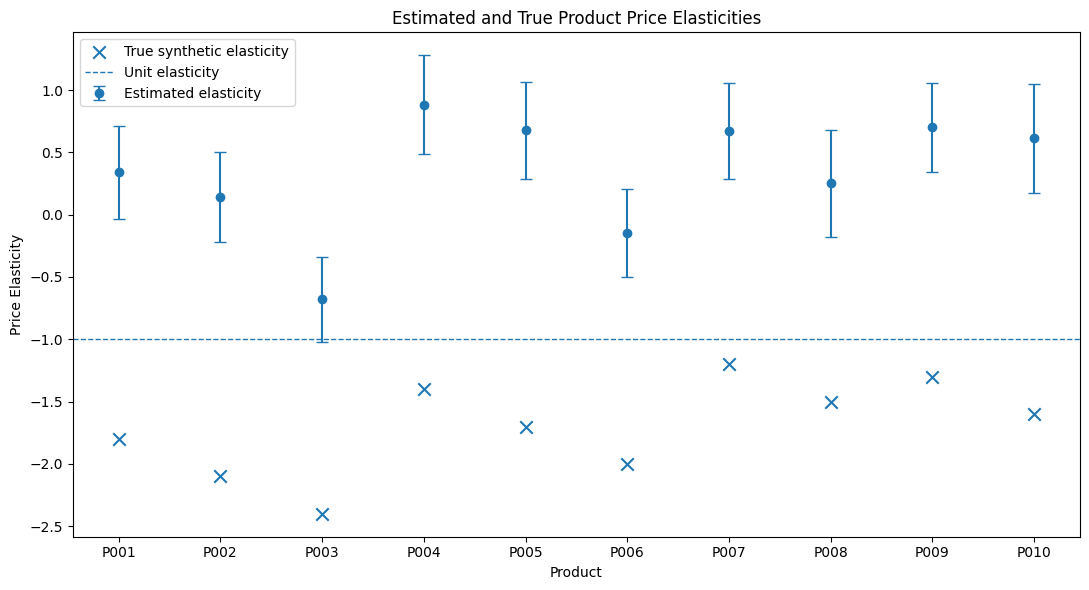

In [12]:
plot_data = product_elasticity.sort_values(
    "product_id"
)

x_positions = np.arange(len(plot_data))

plt.figure(figsize=(11, 6))

plt.errorbar(
    x_positions,
    plot_data["estimated_elasticity"],
    yerr=1.96 * plot_data["standard_error"],
    fmt="o",
    capsize=4,
    label="Estimated elasticity",
)

plt.scatter(
    x_positions,
    plot_data["true_elasticity"],
    marker="x",
    s=80,
    label="True synthetic elasticity",
)

plt.axhline(
    y=-1,
    linestyle="--",
    linewidth=1,
    label="Unit elasticity",
)

plt.xticks(
    x_positions,
    plot_data["product_id"],
)

plt.title("Estimated and True Product Price Elasticities")
plt.xlabel("Product")
plt.ylabel("Price Elasticity")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "estimated_vs_true_elasticity.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [13]:
def classify_elasticity(value: float) -> str:
    """Classify demand using the elasticity magnitude."""

    if value < -1:
        return "Elastic"

    if value > -1:
        return "Inelastic"

    return "Unit elastic"


product_elasticity["elasticity_class"] = (
    product_elasticity["estimated_elasticity"]
    .apply(classify_elasticity)
)

product_elasticity[
    [
        "product_id",
        "category",
        "estimated_elasticity",
        "true_elasticity",
        "elasticity_class",
        "p_value",
    ]
]

,product_id,category,estimated_elasticity,true_elasticity,elasticity_class,p_value
2,P003,Beverages,-0.6805,-2.4000,Inelastic,0.0001
5,P006,Grocery,-0.1470,-2.0000,Inelastic,0.4159
1,P002,Beverages,0.1429,-2.1000,Inelastic,0.4391
7,P008,Household,0.2506,-1.5000,Inelastic,0.2517
0,P001,Beverages,0.3394,-1.8000,Inelastic,0.0736
9,P010,Personal Care,0.6115,-1.6000,Inelastic,0.0058
6,P007,Household,0.6705,-1.2000,Inelastic,0.0007
4,P005,Grocery,0.6751,-1.7000,Inelastic,0.0008
8,P009,Personal Care,0.7019,-1.3000,Inelastic,0.0001
3,P004,Grocery,0.8832,-1.4000,Inelastic,0.0000


In [14]:
selected_product = (
    product_elasticity.iloc[0]["product_id"]
)

selected_elasticity = (
    product_elasticity.loc[
        product_elasticity["product_id"]
        == selected_product,
        "estimated_elasticity",
    ].iloc[0]
)

selected_history = elasticity_data.loc[
    elasticity_data["product_id"]
    == selected_product
]

baseline_price = selected_history[
    "selling_price"
].mean()

baseline_units = selected_history[
    "units_sold"
].mean()

scenario_prices = np.linspace(
    baseline_price * 0.80,
    baseline_price * 1.20,
    41,
)

scenario_units = baseline_units * (
    scenario_prices / baseline_price
) ** selected_elasticity

scenario_revenue = (
    scenario_prices * scenario_units
)

price_scenarios = pd.DataFrame(
    {
        "selling_price": scenario_prices,
        "expected_units": scenario_units,
        "expected_revenue": scenario_revenue,
    }
)

print(f"Selected product: {selected_product}")
print(
    f"Estimated elasticity: "
    f"{selected_elasticity:.3f}"
)

price_scenarios.head()

Selected product: P003
Estimated elasticity: -0.681


,selling_price,expected_units,expected_revenue
0,7.4226,34.1715,253.6422
1,7.5154,33.8839,254.6509
2,7.6082,33.6021,255.6511
3,7.7010,33.3261,256.6431
4,7.7937,33.0556,257.6270


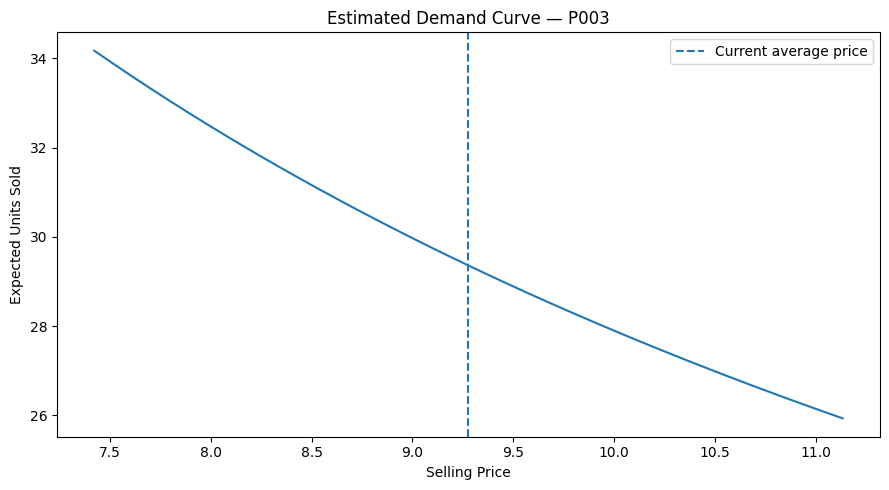

In [15]:
plt.figure(figsize=(9, 5))

plt.plot(
    price_scenarios["selling_price"],
    price_scenarios["expected_units"],
)

plt.axvline(
    baseline_price,
    linestyle="--",
    label="Current average price",
)

plt.title(
    f"Estimated Demand Curve — {selected_product}"
)
plt.xlabel("Selling Price")
plt.ylabel("Expected Units Sold")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "price_demand_scenario.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

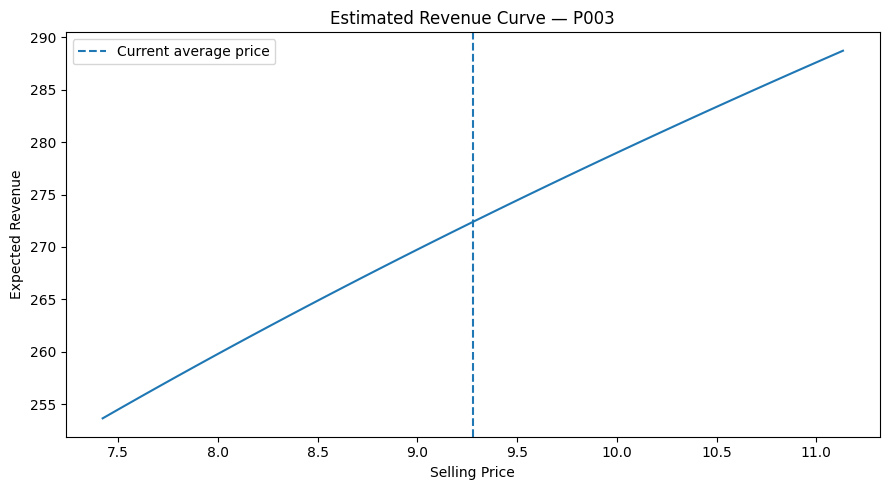

In [16]:
plt.figure(figsize=(9, 5))

plt.plot(
    price_scenarios["selling_price"],
    price_scenarios["expected_revenue"],
)

plt.axvline(
    baseline_price,
    linestyle="--",
    label="Current average price",
)

plt.title(
    f"Estimated Revenue Curve — {selected_product}"
)
plt.xlabel("Selling Price")
plt.ylabel("Expected Revenue")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "price_revenue_scenario.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [17]:
elasticity_output_path = (
    PROCESSED_DATA_DIR
    / "product_elasticity_estimates.csv"
)

product_elasticity.to_csv(
    elasticity_output_path,
    index=False,
)

print(
    f"Elasticity estimates saved to: "
    f"{elasticity_output_path}"
)

Elasticity estimates saved to: c:\Users\marja\OneDrive\Desktop\GitHub\retail-pricing-promotion-optimization\data\processed\product_elasticity_estimates.csv


## Key Findings

- The simple model estimates the unconditional relationship between price and demand.
- The adjusted model controls for competitor prices, promotions, advertising, customer traffic, calendar effects, stores, and products.
- Product-level elasticity differs because products have different levels of price sensitivity.
- Products with elasticity below `-1` are classified as price elastic.
- Products with elasticity between `-1` and `0` are classified as price inelastic.
- Stockout observations were excluded because observed sales may be constrained by inventory availability.
- The synthetic true-elasticity values provide a benchmark for evaluating estimation accuracy.
- Price scenarios illustrate how estimated elasticity can support revenue analysis.
- These results should not yet be interpreted as causal because price-setting decisions may be endogenous.
- The next notebook will use instrumental variables and 2SLS to estimate a more defensible causal price effect.